# Chapter 3 Companion Notebook

**Topic:** The Architecture of Risk Preferences

This notebook is a self-contained computational companion to Chapter 3. It is designed to be **easy to use**, **easy to modify**, and **close to the structure of the chapter**.

## What this notebook does

It focuses on three main tasks:

1. **Rebuilding Figure 3.2** using simple utility specifications that illustrate risk-averse, risk-neutral, and risk-seeking behaviour.
2. **Computing certainty equivalents and risk premia** from user-supplied parameters.
3. **Exploring risk-averse and risk-seeking cases** in a transparent way with clearly separated parameter cells and execution cells.

## How to use this notebook

For each section:

- first modify the **parameter cell**
- then run the **execution cell**
- inspect the graph or printed output
- change the parameters and rerun if needed

The notebook is intentionally structured so that readers can work with it without needing a separate Python module.


## 1. Installation

Install the required libraries first:

```bash
pip install -r requirements.txt
```

Then launch Jupyter and open this notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

def utility_linear(x):
    x = np.asarray(x, dtype=float)
    return x

def utility_power(x, alpha=0.8):
    x = np.asarray(x, dtype=float)
    x = np.maximum(x, 0)
    return x ** alpha

def utility_cara_normalized(x, a=0.03):
    x = np.asarray(x, dtype=float)
    return (1 - np.exp(-a * x)) / a

def utility_crra_shifted(x, r=2.0, shift=1.0):
    x = np.asarray(x, dtype=float)
    z = np.maximum(x + shift, 1e-8)
    if abs(r - 1.0) < 1e-12:
        return np.log(z)
    return (z ** (1 - r) - 1) / (1 - r)

def expected_value(outcomes, probabilities):
    outcomes = np.asarray(outcomes, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    return np.sum(outcomes * probabilities)

def expected_utility(outcomes, probabilities, utility_fn):
    outcomes = np.asarray(outcomes, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    return np.sum(probabilities * utility_fn(outcomes))

def certainty_equivalent_numeric(expected_utility_value, utility_fn, lower=0.0, upper=500.0, grid_size=20000):
    grid = np.linspace(lower, upper, grid_size)
    utilities = utility_fn(grid)
    idx = np.argmin(np.abs(utilities - expected_utility_value))
    return float(grid[idx])

def risk_premium(outcomes, probabilities, utility_fn, lower=0.0, upper=500.0):
    ev = expected_value(outcomes, probabilities)
    eu = expected_utility(outcomes, probabilities, utility_fn)
    ce = certainty_equivalent_numeric(eu, utility_fn, lower=lower, upper=upper)
    rp = ev - ce
    return ev, eu, ce, rp


## 2. Section 3.5 — Rebuilding Figure 3.2

This section replaces the earlier utility-function plot with a notebook version of **Figure 3.2**, the schematic graph showing the three canonical cases:

- **risk averse**: concave utility
- **risk neutral**: linear utility
- **risk seeking**: convex utility

The goal here is not to estimate a behavioural model, but to generate a **clean pedagogical reconstruction** of the figure.

### Suggested interpretation

A simple way to reproduce the three shapes is:

- use a **power utility** with exponent `alpha_averse < 1` for risk aversion
- use a **linear utility** for risk neutrality
- use a **power utility** with exponent `alpha_seeking > 1` for risk seeking

You can modify the parameters below until the visual result matches the chapter figure as closely as you want.


### 2A. Parameter cell for Figure 3.2

Edit the values below and then run the next cell.

Guidelines:
- choose `alpha_averse` between about `0.3` and `0.9`
- choose `alpha_seeking` greater than `1.0`
- increase `wealth_max` if you want a wider horizontal axis
- set `use_normalized_scale=True` if you want the three curves to be visually comparable


In [3]:
# Parameters for rebuilding Figure 3.2

wealth_min = 0
wealth_max = 10
num_points = 400

alpha_averse = 0.45
alpha_seeking = 1.8

use_normalized_scale = True
show_labels_on_curve = True


### 2B. Run to rebuild Figure 3.2


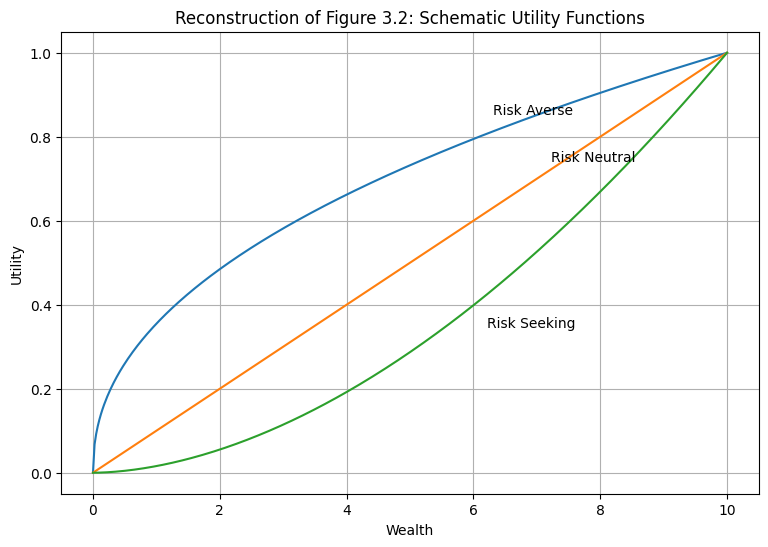

In [4]:
x = np.linspace(wealth_min, wealth_max, num_points)

u_averse = utility_power(x, alpha=alpha_averse)
u_neutral = utility_linear(x)
u_seeking = utility_power(x, alpha=alpha_seeking)

if use_normalized_scale:
    def normalize(y):
        y = np.asarray(y, dtype=float)
        if np.max(y) == np.min(y):
            return y
        return (y - np.min(y)) / (np.max(y) - np.min(y))
    u_averse = normalize(u_averse)
    u_neutral = normalize(u_neutral)
    u_seeking = normalize(u_seeking)

plt.figure(figsize=(9, 6))
plt.plot(x, u_averse, label="Risk Averse")
plt.plot(x, u_neutral, label="Risk Neutral")
plt.plot(x, u_seeking, label="Risk Seeking")

plt.xlabel("Wealth")
plt.ylabel("Utility")
plt.title("Reconstruction of Figure 3.2: Schematic Utility Functions")

if show_labels_on_curve:
    plt.text(x[int(0.63 * len(x))], u_averse[int(0.63 * len(x))] + 0.04, "Risk Averse")
    plt.text(x[int(0.72 * len(x))], u_neutral[int(0.72 * len(x))] + 0.02, "Risk Neutral")
    plt.text(x[int(0.62 * len(x))], u_seeking[int(0.62 * len(x))] - 0.08, "Risk Seeking")

plt.show()


### 2C. Optional alternative specifications

Below, the optional alternative reconstruction is split into two cells:

- one cell for **parameters only**
- one cell for **running the curves**

This makes it easier to experiment with **linear, CARA, and CRRA** specifications without editing the plotting logic.


In [11]:
# Optional alternative parameters
# Use these parameters only for the alternative Linear / CARA / CRRA illustration.

cara_a = 0.35
crra_r = 2.0
crra_shift = 1.0

alt_x_min = 0.0
alt_x_max = 10.0
alt_num_points = 400


### 2D. Run the optional alternative specifications

This cell uses the parameter values defined above and plots normalized versions of the three functions so that their **curvature** can be compared more easily.


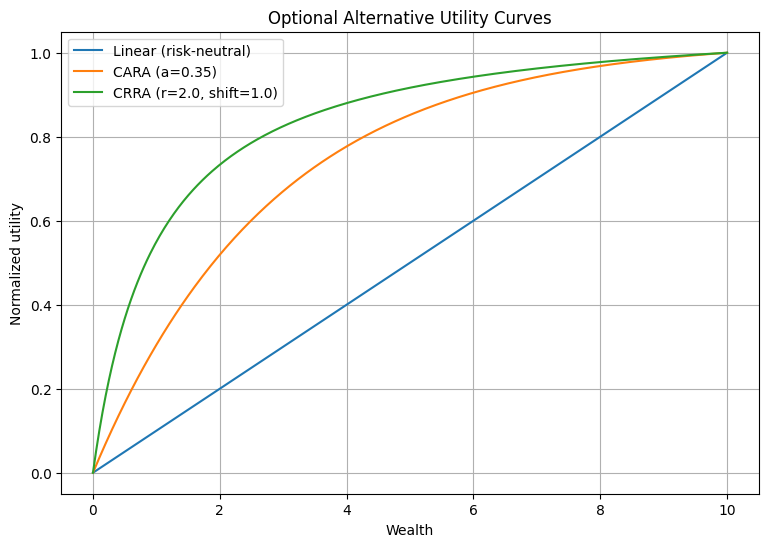

In [12]:
x_alt = np.linspace(alt_x_min, alt_x_max, alt_num_points)
u_linear_alt = utility_linear(x_alt)
u_cara_alt = utility_cara_normalized(x_alt, a=cara_a)
u_crra_alt = utility_crra_shifted(x_alt, r=crra_r, shift=crra_shift)

def normalize(y):
    y = np.asarray(y, dtype=float)
    y_min = np.min(y)
    y_max = np.max(y)
    if np.isclose(y_max, y_min):
        return np.zeros_like(y)
    return (y - y_min) / (y_max - y_min)

plt.figure(figsize=(9, 6))
plt.plot(x_alt, normalize(u_linear_alt), label="Linear (risk-neutral)")
plt.plot(x_alt, normalize(u_cara_alt), label=f"CARA (a={cara_a})")
plt.plot(x_alt, normalize(u_crra_alt), label=f"CRRA (r={crra_r}, shift={crra_shift})")
plt.xlabel("Wealth")
plt.ylabel("Normalized utility")
plt.title("Optional Alternative Utility Curves")
plt.legend()
plt.show()


## 3. Section 3.6 — Certainty Equivalent and Risk Premium

This section is now split into two clearly separated parts:

- a **parameter cell**, where the user only edits the model inputs
- a **run cell**, where the calculations are performed

### Reminder

For a lottery with outcomes \(x_i\) and probabilities \(p_i\):

- expected value: \(EV = \sum_i p_i x_i\)
- expected utility: \(EU = \sum_i p_i u(x_i)\)
- certainty equivalent: the sure amount \(CE\) such that \(u(CE) = EU\)
- risk premium: \(RP = EV - CE\)

For a risk-averse decision maker, the risk premium is typically positive.


### 3A. Parameter cell for certainty equivalent and risk premium

Instructions:

1. Enter the outcomes of the lottery.
2. Enter probabilities that sum to 1.
3. Choose the utility specification.
4. Adjust the relevant parameters.
5. Run the next cell.

Utility choices available in this notebook:
- `"power"`
- `"linear"`
- `"cara"`


In [13]:
# Parameters for certainty equivalent and risk premium

lottery_outcomes = np.array([20, 50, 100], dtype=float)
lottery_probabilities = np.array([0.2, 0.5, 0.3], dtype=float)

utility_choice = "power"   # choose from: "power", "linear", "cara"

# Parameters used depending on utility_choice
power_alpha = 0.7          # risk-averse if < 1, risk-seeking if > 1
cara_a = 0.03              # positive coefficient for CARA

# Numerical inversion range for CE
ce_lower_bound = 0.0
ce_upper_bound = 200.0


### 3B. Run certainty equivalent and risk premium


In [14]:
if not np.isclose(np.sum(lottery_probabilities), 1.0):
    raise ValueError("Probabilities must sum to 1.")

if utility_choice == "power":
    utility_fn = lambda z: utility_power(z, alpha=power_alpha)
    utility_description = f"Power utility with alpha={power_alpha}"
elif utility_choice == "linear":
    utility_fn = utility_linear
    utility_description = "Linear utility"
elif utility_choice == "cara":
    utility_fn = lambda z: utility_cara_normalized(z, a=cara_a)
    utility_description = f"CARA utility with a={cara_a}"
else:
    raise ValueError("utility_choice must be 'power', 'linear', or 'cara'.")

ev, eu, ce, rp = risk_premium(
    lottery_outcomes,
    lottery_probabilities,
    utility_fn,
    lower=ce_lower_bound,
    upper=ce_upper_bound
)

print("Utility specification:", utility_description)
print("Outcomes:", lottery_outcomes)
print("Probabilities:", lottery_probabilities)
print(f"Expected value (EV): {ev:.4f}")
print(f"Expected utility (EU): {eu:.4f}")
print(f"Certainty equivalent (CE): {ce:.4f}")
print(f"Risk premium (RP = EV - CE): {rp:.4f}")


Utility specification: Power utility with alpha=0.7
Outcomes: [ 20.  50. 100.]
Probabilities: [0.2 0.5 0.3]
Expected value (EV): 59.0000
Expected utility (EU): 16.8953
Certainty equivalent (CE): 56.7528
Risk premium (RP = EV - CE): 2.2472


### 3C. Graphical interpretation

To make the graph easier to read, this section is now split into two visualizations:

1. a **utility-curve graph** showing:
   - the utility function
   - the expected utility of the lottery
   - the certainty equivalent on the wealth axis
   - the expected value on the wealth axis

2. a **summary graph** showing:
   - expected value
   - certainty equivalent
   - risk premium

Interpretation:
- the **expected value (EV)** is the average monetary payoff of the lottery
- the **certainty equivalent (CE)** is the sure amount that gives the same utility as the lottery
- the **risk premium (RP)** is `EV - CE`

For a risk-averse decision maker, the CE should lie **to the left of** the EV, so the RP is positive.


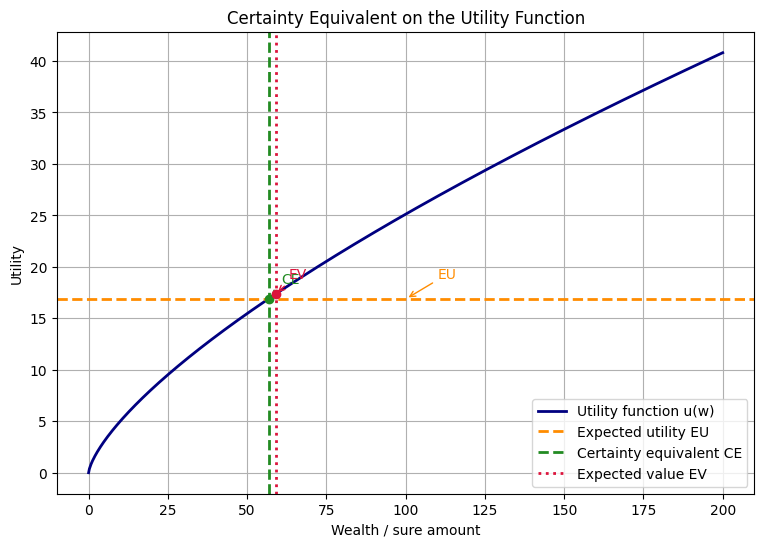

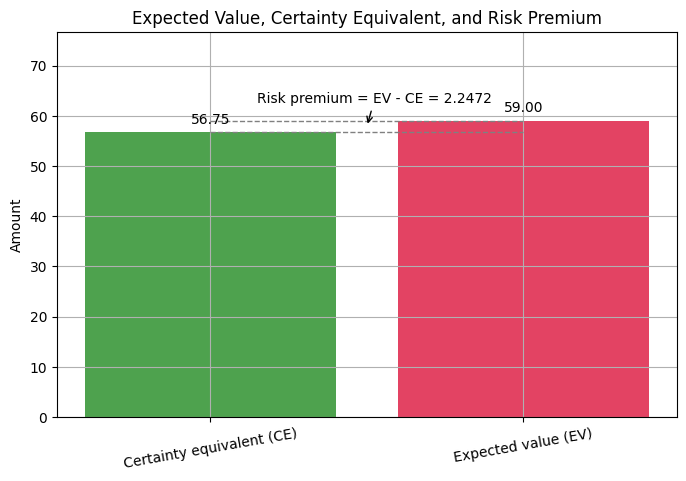

In [20]:
x = np.linspace(ce_lower_bound, ce_upper_bound, 800)
u_x = utility_fn(x)

# Graph 1: utility-based interpretation
plt.figure(figsize=(9, 6))
plt.plot(x, u_x, color="navy", linewidth=2, label="Utility function u(w)")
plt.axhline(eu, color="darkorange", linestyle="--", linewidth=2, label="Expected utility EU")
plt.axvline(ce, color="forestgreen", linestyle="--", linewidth=2, label="Certainty equivalent CE")
plt.axvline(ev, color="crimson", linestyle=":", linewidth=2, label="Expected value EV")

plt.scatter([ce], [utility_fn(np.array([ce]))[0]], color="forestgreen", zorder=5)
plt.scatter([ev], [utility_fn(np.array([ev]))[0]], color="crimson", zorder=5)

plt.annotate("CE", xy=(ce, utility_fn(np.array([ce]))[0]), xytext=(ce + 4, utility_fn(np.array([ce]))[0] + 1.5),
             arrowprops=dict(arrowstyle="->", color="forestgreen"), color="forestgreen")
plt.annotate("EV", xy=(ev, utility_fn(np.array([ev]))[0]), xytext=(ev + 4, utility_fn(np.array([ev]))[0] + 1.5),
             arrowprops=dict(arrowstyle="->", color="crimson"), color="crimson")
plt.annotate("EU", xy=(x[len(x)//2], eu), xytext=(x[len(x)//2] + 10, eu + 2),
             arrowprops=dict(arrowstyle="->", color="darkorange"), color="darkorange")

plt.xlabel("Wealth / sure amount")
plt.ylabel("Utility")
plt.title("Certainty Equivalent on the Utility Function")
plt.legend()
plt.show()

# Graph 2: summary of EV, CE, and RP
plt.figure(figsize=(8, 5))
positions = [0, 1]
values = [ce, ev]
labels = ["Certainty equivalent (CE)", "Expected value (EV)"]

plt.bar(positions, values, color=["forestgreen", "crimson"], alpha=0.8)
plt.xticks(positions, labels, rotation=10)
plt.ylabel("Amount")
plt.title("Expected Value, Certainty Equivalent, and Risk Premium")

mid_x = 0.5
plt.plot([0, 1], [ce, ce], color="gray", linestyle="--", linewidth=1)
plt.plot([0, 1], [ev, ev], color="gray", linestyle="--", linewidth=1)
plt.annotate(f"Risk premium = EV - CE = {rp:.4f}",
             xy=(mid_x, (ce + ev) / 2),
             xytext=(0.15, (ce + ev) / 2 + max(ev, ce) * 0.08),
             arrowprops=dict(arrowstyle="->", color="black"),
             color="black")

for pos, val in zip(positions, values):
    plt.text(pos, val + max(values) * 0.03, f"{val:.2f}", ha="center")

plt.ylim(0, max(values) * 1.3)
plt.show()


## 4. Sections 3.7 and 3.8 — Risk-Averse and Risk-Seeking Behaviour

This section also uses the same logic:
- first a **parameter cell**
- then an **execution cell**

The idea is to let the reader compare how different curvatures change the evaluation of the same lottery.

### Interpretation

Using power utility:
- `alpha < 1` gives a concave function and risk aversion
- `alpha = 1` gives a linear function and risk neutrality
- `alpha > 1` gives a convex function and risk seeking


### 4A. Parameter cell for the comparative graphs

Instructions:

1. Enter a lottery.
2. Enter one parameter for the risk-averse case and one for the risk-seeking case.
3. Run the following cells to generate the utility curves and the certainty-equivalent comparison.


In [16]:
# Parameters for comparative risk-attitude analysis

comparison_outcomes = np.array([10, 90], dtype=float)
comparison_probabilities = np.array([0.5, 0.5], dtype=float)

alpha_risk_averse = 0.6
alpha_risk_neutral = 1.0
alpha_risk_seeking = 1.4

comparison_x_min = 0.0
comparison_x_max = 120.0


### 4B. Plot the three utility curves


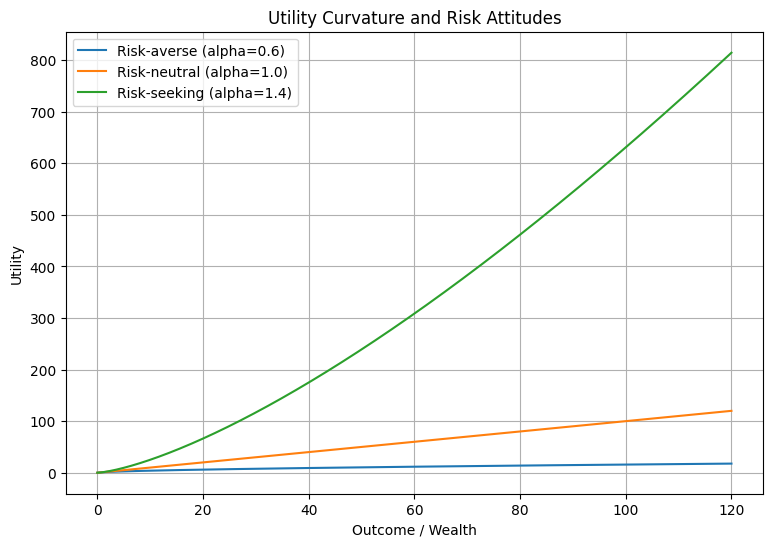

In [17]:
x = np.linspace(comparison_x_min, comparison_x_max, 600)

u_ra = utility_power(x, alpha=alpha_risk_averse)
u_rn = utility_power(x, alpha=alpha_risk_neutral)
u_rs = utility_power(x, alpha=alpha_risk_seeking)

plt.figure(figsize=(9, 6))
plt.plot(x, u_ra, label=f"Risk-averse (alpha={alpha_risk_averse})")
plt.plot(x, u_rn, label=f"Risk-neutral (alpha={alpha_risk_neutral})")
plt.plot(x, u_rs, label=f"Risk-seeking (alpha={alpha_risk_seeking})")
plt.xlabel("Outcome / Wealth")
plt.ylabel("Utility")
plt.title("Utility Curvature and Risk Attitudes")
plt.legend()
plt.show()


### 4C. Compare certainty equivalents under the three cases

As in Section 3.6, this part separates the analysis into:
- a **numerical summary**
- a **utility-curve graph**
- a **simple comparison graph** for expected value, certainty equivalents, and risk premia

This makes it easier to see which certainty equivalent belongs to which utility function.


In [18]:
utility_ra = lambda z: utility_power(z, alpha=alpha_risk_averse)
utility_rn = lambda z: utility_power(z, alpha=alpha_risk_neutral)
utility_rs = lambda z: utility_power(z, alpha=alpha_risk_seeking)

ev_ra, eu_ra, ce_ra, rp_ra = risk_premium(comparison_outcomes, comparison_probabilities, utility_ra, lower=comparison_x_min, upper=comparison_x_max)
ev_rn, eu_rn, ce_rn, rp_rn = risk_premium(comparison_outcomes, comparison_probabilities, utility_rn, lower=comparison_x_min, upper=comparison_x_max)
ev_rs, eu_rs, ce_rs, rp_rs = risk_premium(comparison_outcomes, comparison_probabilities, utility_rs, lower=comparison_x_min, upper=comparison_x_max)

print("Lottery outcomes:", comparison_outcomes)
print("Lottery probabilities:", comparison_probabilities)
print()
print(f"Expected value: {ev_ra:.4f}")
print()
print(f"Risk-averse CE:  {ce_ra:.4f} | Risk premium: {rp_ra:.4f}")
print(f"Risk-neutral CE: {ce_rn:.4f} | Risk premium: {rp_rn:.4f}")
print(f"Risk-seeking CE: {ce_rs:.4f} | Risk premium: {rp_rs:.4f}")


Lottery outcomes: [10. 90.]
Lottery probabilities: [0.5 0.5]

Expected value: 50.0000

Risk-averse CE:  42.0861 | Risk premium: 7.9139
Risk-neutral CE: 50.0005 | Risk premium: -0.0005
Risk-seeking CE: 56.6488 | Risk premium: -6.6488


### 4D. Graphical comparison of certainty equivalents

The first graph keeps the three utility functions together, but now adds:
- matching colors for each case
- horizontal expected-utility lines
- vertical certainty-equivalent lines
- labels showing which CE belongs to which curve

The second graph simplifies the comparison by plotting:
- the common expected value of the lottery
- each certainty equivalent
- each risk premium

This should make the interpretation substantially easier.


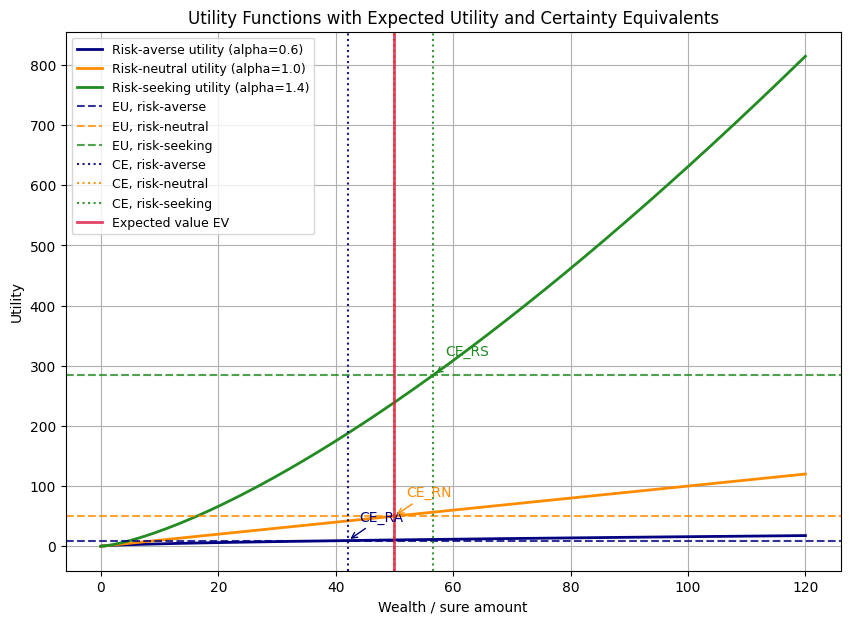

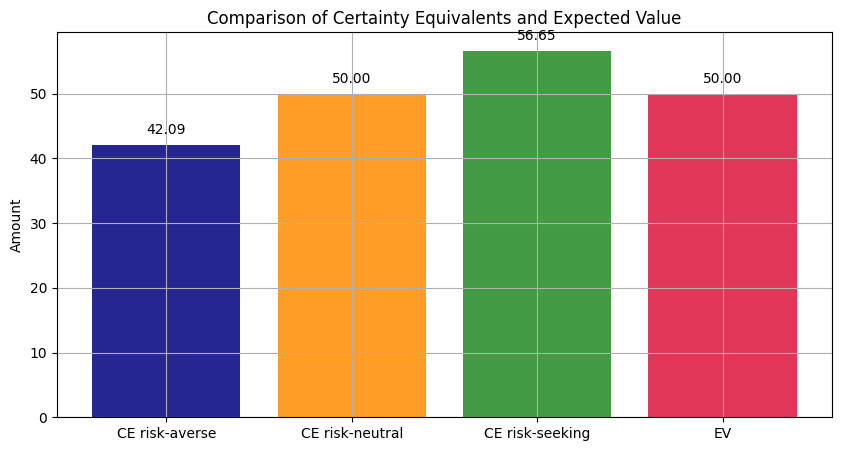

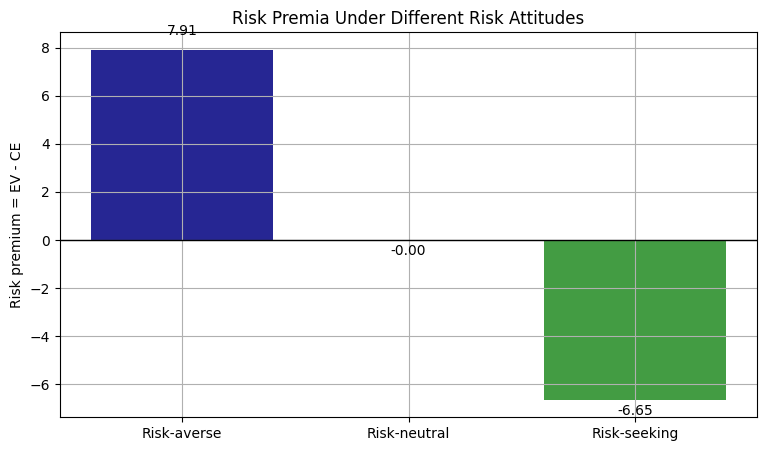

In [21]:
x = np.linspace(comparison_x_min, comparison_x_max, 600)

# Graph 1: utility functions with their own EU and CE markers
plt.figure(figsize=(10, 7))
plt.plot(x, utility_ra(x), color="navy", linewidth=2, label=f"Risk-averse utility (alpha={alpha_risk_averse})")
plt.plot(x, utility_rn(x), color="darkorange", linewidth=2, label=f"Risk-neutral utility (alpha={alpha_risk_neutral})")
plt.plot(x, utility_rs(x), color="forestgreen", linewidth=2, label=f"Risk-seeking utility (alpha={alpha_risk_seeking})")

plt.axhline(eu_ra, color="navy", linestyle="--", alpha=0.8, label="EU, risk-averse")
plt.axhline(eu_rn, color="darkorange", linestyle="--", alpha=0.8, label="EU, risk-neutral")
plt.axhline(eu_rs, color="forestgreen", linestyle="--", alpha=0.8, label="EU, risk-seeking")

plt.axvline(ce_ra, color="navy", linestyle=":", alpha=0.9, label="CE, risk-averse")
plt.axvline(ce_rn, color="darkorange", linestyle=":", alpha=0.9, label="CE, risk-neutral")
plt.axvline(ce_rs, color="forestgreen", linestyle=":", alpha=0.9, label="CE, risk-seeking")
plt.axvline(ev_ra, color="crimson", linewidth=2, alpha=0.8, label="Expected value EV")

plt.annotate("CE_RA", xy=(ce_ra, utility_ra(np.array([ce_ra]))[0]),
             xytext=(ce_ra + 2, utility_ra(np.array([ce_ra]))[0] + max(utility_rs(x)) * 0.04),
             arrowprops=dict(arrowstyle="->", color="navy"), color="navy")
plt.annotate("CE_RN", xy=(ce_rn, utility_rn(np.array([ce_rn]))[0]),
             xytext=(ce_rn + 2, utility_rn(np.array([ce_rn]))[0] + max(utility_rs(x)) * 0.04),
             arrowprops=dict(arrowstyle="->", color="darkorange"), color="darkorange")
plt.annotate("CE_RS", xy=(ce_rs, utility_rs(np.array([ce_rs]))[0]),
             xytext=(ce_rs + 2, utility_rs(np.array([ce_rs]))[0] + max(utility_rs(x)) * 0.04),
             arrowprops=dict(arrowstyle="->", color="forestgreen"), color="forestgreen")

plt.xlabel("Wealth / sure amount")
plt.ylabel("Utility")
plt.title("Utility Functions with Expected Utility and Certainty Equivalents")
plt.legend(loc="upper left", fontsize=9)
plt.show()

# Graph 2: simple comparison of EV and CE values
plt.figure(figsize=(10, 5))
bar_labels = [
    "CE risk-averse",
    "CE risk-neutral",
    "CE risk-seeking",
    "EV"
]
bar_values = [ce_ra, ce_rn, ce_rs, ev_ra]
bar_colors = ["navy", "darkorange", "forestgreen", "crimson"]

plt.bar(bar_labels, bar_values, color=bar_colors, alpha=0.85)
plt.ylabel("Amount")
plt.title("Comparison of Certainty Equivalents and Expected Value")

for i, value in enumerate(bar_values):
    plt.text(i, value + max(bar_values) * 0.03, f"{value:.2f}", ha="center")

plt.show()

# Graph 3: risk premia by attitude
plt.figure(figsize=(9, 5))
rp_labels = ["Risk-averse", "Risk-neutral", "Risk-seeking"]
rp_values = [rp_ra, rp_rn, rp_rs]
rp_colors = ["navy", "darkorange", "forestgreen"]

plt.bar(rp_labels, rp_values, color=rp_colors, alpha=0.85)
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Risk premium = EV - CE")
plt.title("Risk Premia Under Different Risk Attitudes")

for i, value in enumerate(rp_values):
    offset = max(abs(min(rp_values)), abs(max(rp_values))) * 0.08 if any(v != 0 for v in rp_values) else 0.1
    plt.text(i, value + (offset if value >= 0 else -offset), f"{value:.2f}", ha="center")

plt.show()


## 5. Notes on interpretation

- The **St. Petersburg plot** has been removed from the main notebook flow, since you noted that it is too trivial for present purposes.
- Section 3.5 has been reoriented toward **rebuilding Figure 3.2**, which is more aligned with the chapter.
- The notebook now separates **parameter cells** from **execution cells** in the sections where readers are expected to modify inputs.
- The notebook uses simple and transparent specifications so that it works well as a teaching and replication companion.
